# Electricity Consumption Prediction using ANN (Time Series)

**Objective:** Predict next-day household electricity consumption using an Artificial Neural Network trained on historical lag-based features.

**Dataset:** UCI Household Power Consumption (2006-2010, minute-wise readings)

**Approach:** Data Cleaning → Daily Resampling → Lag Feature Engineering → ANN (Keras) → Evaluation

## 1. Data Loading & Cleaning
## 2. Exploratory Data Analysis
## 3. Feature Engineering (Lag Features)
## 4. Train-Test Split & Scaling
## 5. ANN Model Building & Training
## 6. Evaluation
## 7. Interactive Prediction

## Conclusion

- Built an ANN model to predict daily electricity consumption using lag-based time series features
- Achieved Test MAE of ~0.21 kW on unseen data
- Model captures overall trend and seasonality well, though slightly underestimates sudden spikes
- Future improvements: LSTM/GRU for better sequence modeling, adding weather data as external features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\riyar\Downloads\household_power_consumption.txt.zip"
    ,
    sep=';',
    na_values=['?'],
    low_memory=False
)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
print(df.shape)
print(df.isnull().sum())

(2075259, 9)
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [4]:
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.drop(['Date', 'Time'], axis=1)
df = df.set_index('DateTime')
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [7]:
df = df.interpolate(method='time')
print(df.isnull().sum())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [8]:
daily_df = df['Global_active_power'].resample('D').mean()
print(daily_df.shape)
daily_df.head()

(1442,)


DateTime
2006-12-16    3.053475
2006-12-17    2.354486
2006-12-18    1.530435
2006-12-19    1.157079
2006-12-20    1.545658
Freq: D, Name: Global_active_power, dtype: float64

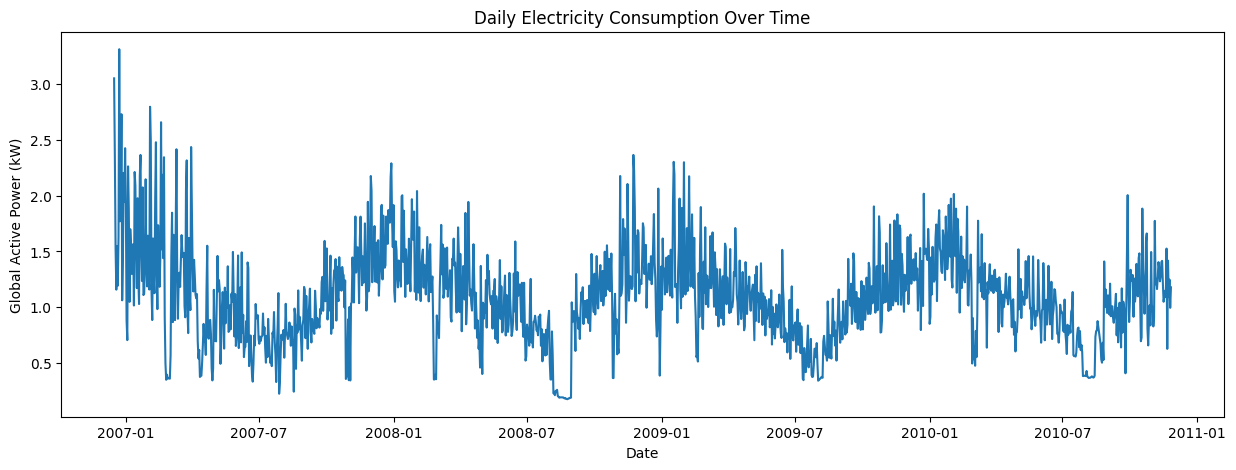

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(daily_df)
plt.title('Daily Electricity Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.show()

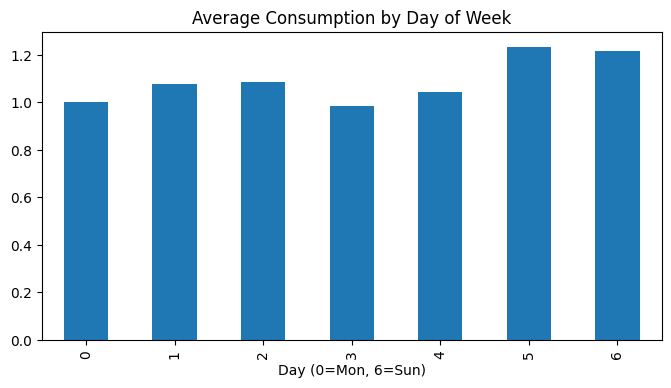

In [10]:
df['DayOfWeek'] = df.index.dayofweek  # 0=Monday, 6=Sunday
weekly_avg = df.groupby('DayOfWeek')['Global_active_power'].mean()
weekly_avg.plot(kind='bar', figsize=(8,4))
plt.title('Average Consumption by Day of Week')
plt.xlabel('Day (0=Mon, 6=Sun)')
plt.show()

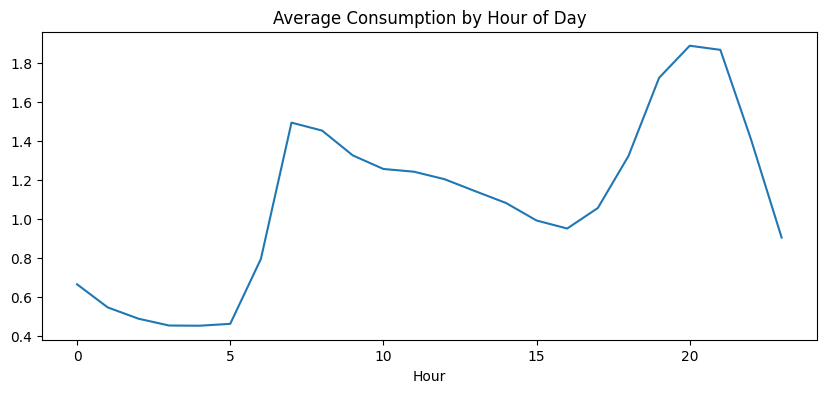

In [11]:
hourly_avg = df.groupby(df.index.hour)['Global_active_power'].mean()
hourly_avg.plot(figsize=(10,4))
plt.title('Average Consumption by Hour of Day')
plt.xlabel('Hour')
plt.show()

In [12]:
print(daily_df.describe())

count    1442.000000
mean        1.091274
std         0.421111
min         0.173818
25%         0.811181
50%         1.079206
75%         1.322892
max         3.314851
Name: Global_active_power, dtype: float64


In [13]:
df[['Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].corr()

,Global_active_power,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.000000,0.483816,0.433892,0.639272
Sub_metering_1,0.483816,1.000000,0.055011,0.102704
Sub_metering_2,0.433892,0.055011,1.000000,0.080710
Sub_metering_3,0.639272,0.102704,0.080710,1.000000


In [14]:
df_ann = pd.DataFrame(daily_df)
df_ann.columns = ['Consumption']

# Lag features banao
df_ann['Lag_1'] = df_ann['Consumption'].shift(1)   # kal ki value
df_ann['Lag_2'] = df_ann['Consumption'].shift(2)   # parso ki value
df_ann['Lag_3'] = df_ann['Consumption'].shift(3)
df_ann['Lag_7'] = df_ann['Consumption'].shift(7)   # ek hafta pehle ki value

df_ann = df_ann.dropna()   # shuru ki rows jinme lag values nahi hain (NaN), unhe hata do
print(df_ann.shape)
df_ann.head(10)

(1435, 5)


,Consumption,Lag_1,Lag_2,Lag_3,Lag_7
DateTime,,,,,
2006-12-23,3.314851,1.625929,1.192440,1.545658,3.053475
2006-12-24,1.770842,3.314851,1.625929,1.192440,2.354486
2006-12-25,1.904944,1.770842,3.314851,1.625929,1.530435
2006-12-26,2.732021,1.904944,1.770842,3.314851,1.157079
2006-12-27,1.061639,2.732021,1.904944,1.770842,1.545658
2006-12-28,1.439332,1.061639,2.732021,1.904944,1.192440
2006-12-29,2.204439,1.439332,1.061639,2.732021,1.625929
2006-12-30,1.946067,2.204439,1.439332,1.061639,3.314851
2006-12-31,2.426525,1.946067,2.204439,1.439332,1.770842


In [15]:
X = df_ann.drop('Consumption', axis=1)   # sab lag features (input)
y = df_ann['Consumption']                 # asli consumption (jo predict karna hai)

print(X.shape, y.shape)
X.head()

(1435, 4) (1435,)


,Lag_1,Lag_2,Lag_3,Lag_7
DateTime,,,,
2006-12-23,1.625929,1.192440,1.545658,3.053475
2006-12-24,3.314851,1.625929,1.192440,2.354486
2006-12-25,1.770842,3.314851,1.625929,1.530435
2006-12-26,1.904944,1.770842,3.314851,1.157079
2006-12-27,2.732021,1.904944,1.770842,1.545658


In [16]:
split_point = int(len(df_ann) * 0.8)

X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1148, 4)
Test size: (287, 4)


In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# IMPORTANT: scaler ko sirf TRAIN data pe "fit" karte hain
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # test pe sirf "transform", fit nahi

In [19]:
import tensorflow as tf
print(tf.__version__)

2.10.1


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),  # input layer + 1st hidden layer
    Dense(32, activation='relu'),                                          # 2nd hidden layer
    Dense(16, activation='relu'),                                          # 3rd hidden layer
    Dense(1)                                                               # output layer (regression, no activation)
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                320       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 2,945
Trainable params: 2,945
Non-trainable params: 0
_________________________________________________________________


In [21]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [22]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,      # training data ka 10% validation ke liye alag rakho
    epochs=100,                 # pura dataset 100 baar dekhega model
    batch_size=16,               # ek baar mein 16 rows dekh ke weight update karega
    verbose=1
)

Epoch 1/100
65/65 [==============================] - 3s 16ms/step - loss: 0.8932 - mae: 0.8135 - val_loss: 0.1784 - val_mae: 0.3445
Epoch 2/100
65/65 [==============================] - 0s 6ms/step - loss: 0.1162 - mae: 0.2521 - val_loss: 0.0860 - val_mae: 0.2296
Epoch 3/100
65/65 [==============================] - 0s 6ms/step - loss: 0.1058 - mae: 0.2413 - val_loss: 0.0900 - val_mae: 0.2322
Epoch 4/100
65/65 [==============================] - 0s 5ms/step - loss: 0.1039 - mae: 0.2378 - val_loss: 0.0868 - val_mae: 0.2299
Epoch 5/100
65/65 [==============================] - 0s 6ms/step - loss: 0.1019 - mae: 0.2344 - val_loss: 0.0857 - val_mae: 0.2293
Epoch 6/100
65/65 [==============================] - 0s 6ms/step - loss: 0.1000 - mae: 0.2311 - val_loss: 0.0813 - val_mae: 0.2280
Epoch 7/100
65/65 [==============================] - 0s 6ms/step - loss: 0.0993 - mae: 0.2331 - val_loss: 0.0813 - val_mae: 0.2257
Epoch 8/100
65/65 [==============================] - 0s 4ms/step - loss: 0.0981 - 

In [23]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print("Test MAE:", test_mae)

predictions = model.predict(X_test_scaled)

9/9 [==============================] - 0s 2ms/step - loss: 0.0713 - mae: 0.1976
Test MAE: 0.19758577644824982
9/9 [==============================] - 0s 1ms/step


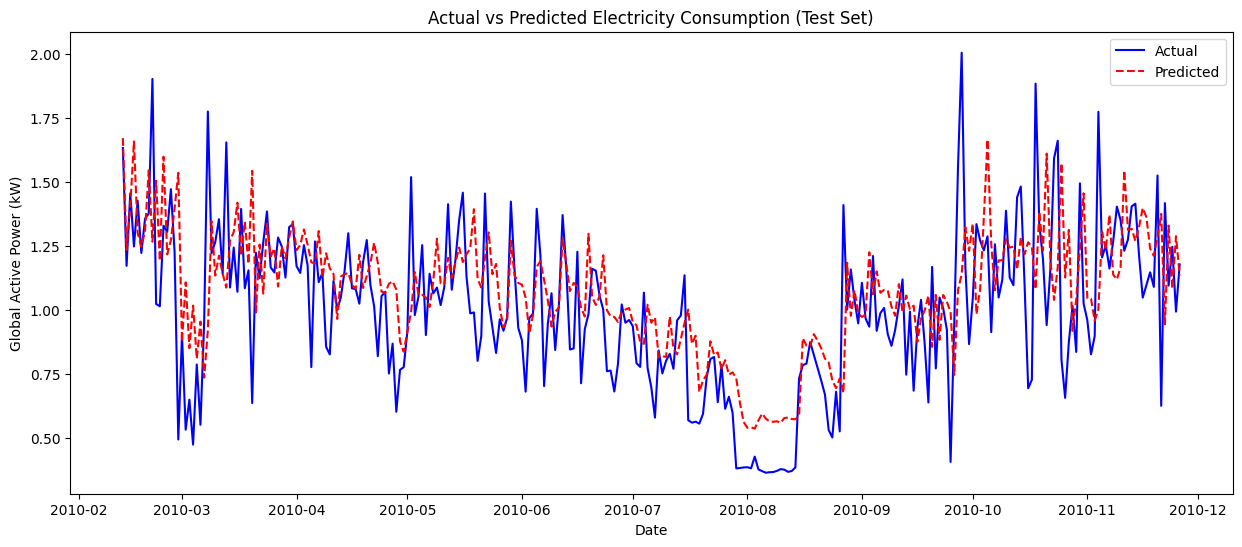

In [24]:
plt.figure(figsize=(15,6))
plt.plot(y_test.index, y_test.values, label='Actual', color='blue')
plt.plot(y_test.index, predictions, label='Predicted', color='red', linestyle='--')
plt.title('Actual vs Predicted Electricity Consumption (Test Set)')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.show()

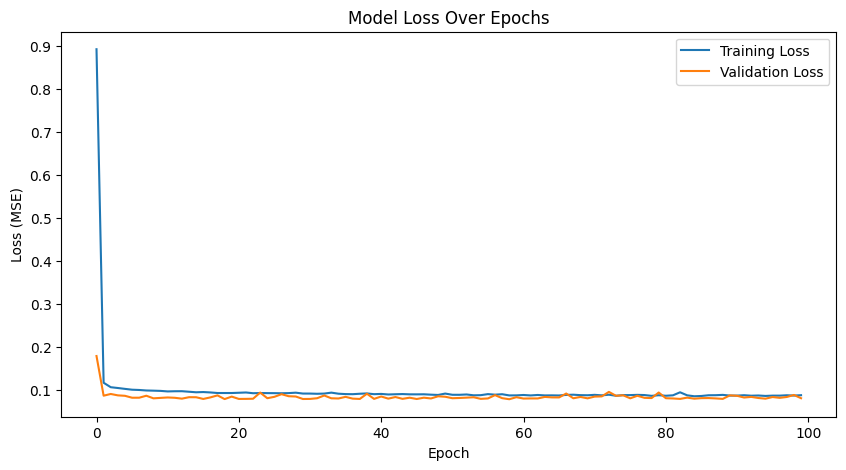

In [25]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [26]:
def predict_consumption(lag1, lag2, lag3, lag7):
    """
    lag1 = kal ka consumption (kW)
    lag2 = parso ka consumption (kW)
    lag3 = 3 din pehle ka consumption (kW)
    lag7 = 1 hafta pehle ka consumption (kW)
    """
    # Input ko DataFrame banao (same column order jo training mein tha)
    input_data = pd.DataFrame([[lag1, lag2, lag3, lag7]], 
                                columns=['Lag_1', 'Lag_2', 'Lag_3', 'Lag_7'])
    
    # SAME scaler use karo jo training mein fit kiya tha (naya fit mat karo!)
    input_scaled = scaler.transform(input_data)
    
    # Prediction
    prediction = model.predict(input_scaled, verbose=0)
    
    print(f"Predicted consumption for tomorrow: {prediction[0][0]:.2f} kW")
    return prediction[0][0]

# Test karke dekho:
predict_consumption(lag1=1.5, lag2=1.6, lag3=1.4, lag7=1.55)

Predicted consumption for tomorrow: 1.48 kW


1.4794059

In [27]:
print("=== Electricity Consumption Predictor ===")
print("Pichle 4 dino ka consumption (kW mein) enter karo:\n")

lag1 = float(input("Kal ka consumption (kW): "))
lag2 = float(input("Parso ka consumption (kW): "))
lag3 = float(input("3 din pehle ka consumption (kW): "))
lag7 = float(input("1 hafta pehle ka consumption (kW): "))

result = predict_consumption(lag1, lag2, lag3, lag7)
print(f"\n✅ Predicted consumption for tomorrow: {result:.2f} kW")

=== Electricity Consumption Predictor ===
Pichle 4 dino ka consumption (kW mein) enter karo:



ValueError: could not convert string to float: ''

In [ ]:
df_ann.tail()

,Consumption,Lag_1,Lag_2,Lag_3,Lag_7
DateTime,,,,,
2010-11-22,1.417733,0.625632,1.525699,1.090556,1.213460
2010-11-23,1.095511,1.417733,0.625632,1.525699,1.048436
2010-11-24,1.247394,1.095511,1.417733,0.625632,1.098633
2010-11-25,0.993864,1.247394,1.095511,1.417733,1.147328
2010-11-26,1.178230,0.993864,1.247394,1.095511,1.090556


In [ ]:
predict_consumption(lag1=1.178230, lag2=0.993864, lag3=1.247394, lag7=1.090556)

Predicted consumption for tomorrow: 1.18 kW


1.1811101

In [28]:

model.save('electricity_ann_model.h5')
print("Model saved successfully!")

Model saved successfully!


In [29]:
import pickle

# Model save karo
model.save('electricity_model.h5')

# Scaler save karo (pickle format mein, kyunki scaler ek Python object hai)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model aur Scaler successfully save ho gaye!")

Model aur Scaler successfully save ho gaye!
